# Modeling — Linear Regression
## Prediksi Hasil Panen Tanaman Berbasis Data Iklim dan Nutrisi Tanaman

| Informasi | Detail |
|-----------|--------|
| Algoritma | Linear Regression |
| Target | `yield_hg_ha` (hasil panen dalam hg/ha) |
| Fitur | area, item, year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp |
| Data Train | X_train.csv / y_train.csv |
| Data Test | X_test.csv / y_test.csv |

---

## 0. Import Library dan Load Data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('output', exist_ok=True)

X_train = pd.read_csv('output/X_train.csv')
X_test  = pd.read_csv('output/X_test.csv')
y_train = pd.read_csv('output/y_train.csv').squeeze()
y_test  = pd.read_csv('output/y_test.csv').squeeze()

print('Data berhasil dimuat.')
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

Data berhasil dimuat.
X_train : (22593, 6)
X_test  : (5649, 6)
y_train : (22593,)
y_test  : (5649,)


---
## 5.1 Training Model Linear Regression

In [2]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model berhasil dilatih.')
print('Konfigurasi Model:')
print(f'  fit_intercept : {model.fit_intercept}')
print(f'  intercept     : {model.intercept_:.4f}')

Model berhasil dilatih.
Konfigurasi Model:
  fit_intercept : True
  intercept     : -2038543.4869


---
## 6.1 Evaluasi Model

In [3]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

print('Evaluasi Model Linear Regression')
print('=======================================')
print(f'  Data Train  -> MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R2: {r2_train:.4f}')
print(f'  Data Test   -> MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R2: {r2_test:.4f}')

Evaluasi Model Linear Regression
  Data Train  -> MAE: 62061.55 | RMSE: 81026.56 | R2: 0.0892
  Data Test   -> MAE: 62321.04 | RMSE: 81181.08 | R2: 0.0914


---
## 6.2 Visualisasi Prediksi vs Aktual

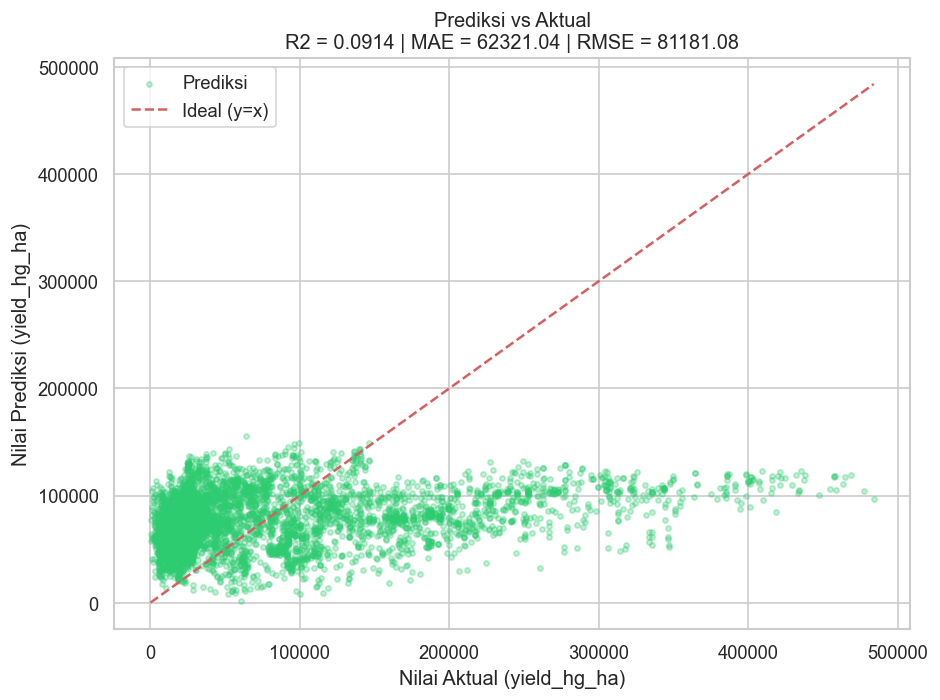

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='#2ECC71', label='Prediksi')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Ideal (y=x)')

ax.set_xlabel('Nilai Aktual (yield_hg_ha)')
ax.set_ylabel('Nilai Prediksi (yield_hg_ha)')
ax.set_title(f'Prediksi vs Aktual\nR2 = {r2_test:.4f} | MAE = {mae_test:.2f} | RMSE = {rmse_test:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('output/modeling_lr_pred_vs_actual.png', bbox_inches='tight')
plt.show()

---
## 6.3 Distribusi Error (Residual)

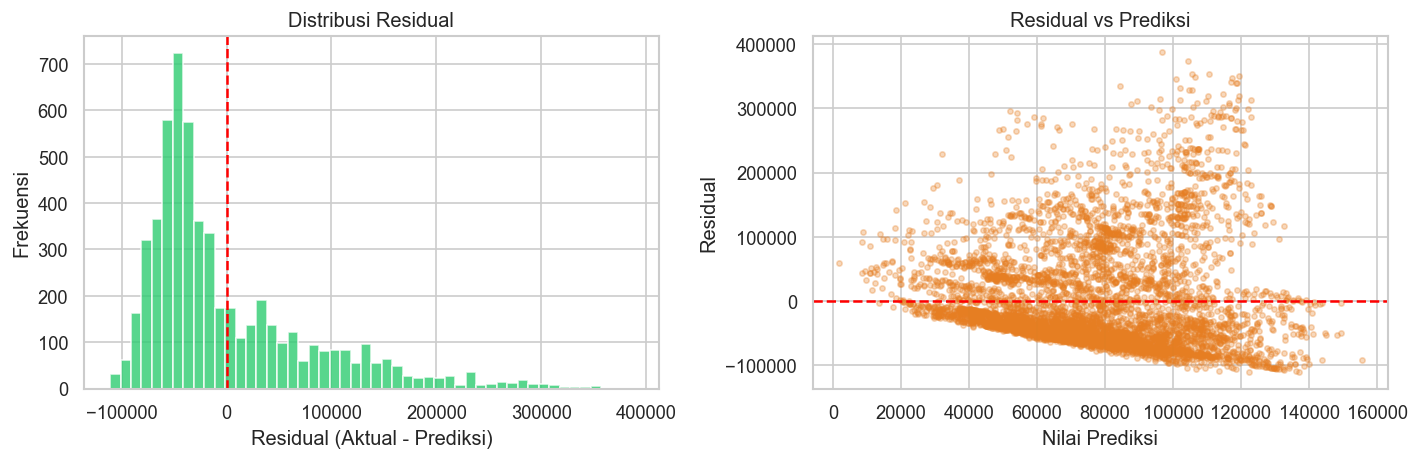

In [5]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, color='#2ECC71', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (Aktual - Prediksi)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Residual')

axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=10, color='#E67E22')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Nilai Prediksi')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs Prediksi')

plt.tight_layout()
plt.savefig('output/modeling_lr_residual.png', bbox_inches='tight')
plt.show()

---
## 7.1 Koefisien Model

In [6]:
feature_names = X_train.columns.tolist()
coefficients  = model.coef_

coef_df = pd.DataFrame({
    'Fitur': feature_names,
    'Koefisien': coefficients
}).sort_values('Koefisien', key=abs, ascending=False).reset_index(drop=True)

print('Koefisien Model (diurutkan berdasarkan besaran pengaruh):')
print('=============================================================================')
for _, row in coef_df.iterrows():
    print(f"  {row['Fitur']:<40}: {row['Koefisien']:>12.4f}")

Koefisien Model (diurutkan berdasarkan besaran pengaruh):
  item                                    :   -7779.9620
  avg_temp                                :   -1819.7991
  year                                    :    1083.7199
  area                                    :     130.3598
  average_rain_fall_mm_per_year           :       3.0147
  pesticides_tonnes                       :       0.2860


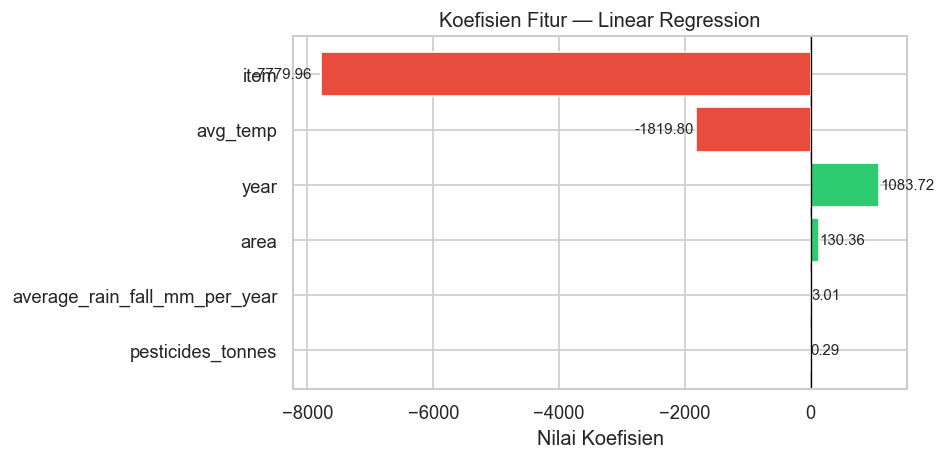

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_coef = ['#E74C3C' if v < 0 else '#2ECC71' for v in coef_df['Koefisien'][::-1]]
bars = ax.barh(coef_df['Fitur'][::-1], coef_df['Koefisien'][::-1],
               color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Nilai Koefisien')
ax.set_title('Koefisien Fitur — Linear Regression')
for bar, val in zip(bars, coef_df['Koefisien'][::-1]):
    offset = abs(val) * 0.02 if val != 0 else 0.01
    ha = 'left' if val >= 0 else 'right'
    x_pos = val + offset if val >= 0 else val - offset
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('output/modeling_lr_coefficients.png', bbox_inches='tight')
plt.show()

---
## 7.2 Rangkuman Hasil dan Kesimpulan

In [8]:
print('=' * 60)
print('  RANGKUMAN HASIL MODELING')
print('=' * 60)
print(f'  Algoritma        : Linear Regression')
print(f'  fit_intercept    : {model.fit_intercept}')
print()
print(f'  Metrik Evaluasi (Data Test):')
print(f'    MAE    : {mae_test:.2f}')
print(f'    RMSE   : {rmse_test:.2f}')
print(f'    R2     : {r2_test:.4f}')
print()
print(f'  Fitur dengan koefisien absolut terbesar:')
for i, row in coef_df.head(3).iterrows():
    print(f"    {i+1}. {row['Fitur']} ({row['Koefisien']:.4f})")
print('=' * 60)

  RANGKUMAN HASIL MODELING
  Algoritma        : Linear Regression
  fit_intercept    : True

  Metrik Evaluasi (Data Test):
    MAE    : 62321.04
    RMSE   : 81181.08
    R2     : 0.0914

  Fitur dengan koefisien absolut terbesar:
    1. item (-7779.9620)
    2. avg_temp (-1819.7991)
    3. year (1083.7199)
